In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sn

In [2]:
digits = load_digits()
X = digits.data      
y = digits.target    

print("Dataset shape:", X.shape)
print("Number of classes:", len(set(y))) 

Dataset shape: (1797, 64)
Number of classes: 10


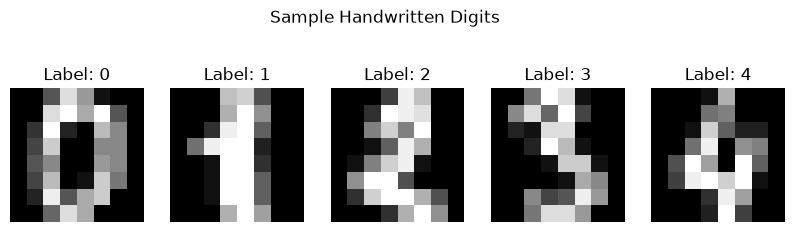

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')
plt.suptitle("Sample Handwritten Digits")
plt.show() 

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
) 

In [5]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test) 

In [6]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print("\nClassification Report:\n", classification_report(y_test, y_pred)) 

Accuracy: 0.9815 (98.15%)

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.98      0.98      0.98        52
           2       0.98      0.98      0.98        53
           3       0.98      0.98      0.98        54
           4       1.00      0.98      0.99        48
           5       0.96      0.96      0.96        57
           6       0.97      1.00      0.98        60
           7       0.96      1.00      0.98        53
           8       1.00      0.95      0.97        61
           9       0.98      0.98      0.98        57

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



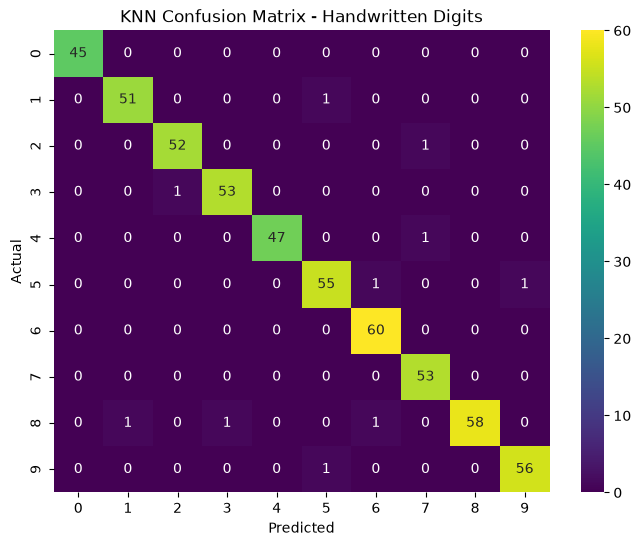

In [7]:
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sn.heatmap(conf_mat, annot=True, fmt='d', cmap='viridis')
plt.title('KNN Confusion Matrix - Handwritten Digits')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show() 

In [8]:
new_sample = X_test[0].reshape(1, -1)
predicted_class = knn.predict(new_sample)
print(f"Predicted class for new sample: {predicted_class[0]}")
print(f"Actual class: {y_test[0]}") 

Predicted class for new sample: 2
Actual class: 2
